# Traditional DSP-Based HR Estimation from synchronous PPG and ACC data

In this notebook, a classical approach is taken to estimate HR from the DaLiA PPG dataset.



In [1]:
# Imports

import numpy as np
import matplotlib.pyplot as plt
import pickle as pkl
from scipy.fft import rfft, rfftfreq

%matplotlib widget
plt.close('all')

In [2]:
# Load data

PREPROC_PATH = "/Volumes/LPM02 storage/Datasets/Bio/DaLiA/data/data_preproc_fs32.pkl"

with open(PREPROC_PATH, 'rb') as f:
    preproc = pkl.load(f)

data_preproc = preproc['data']
params       = preproc['params']

# Unpack params as module-level constants
FS        = params['FS']
BPF_FC1   = params['BPF_FC1']
BPF_FC2   = params['BPF_FC2']
BPF_ORDER = params['BPF_ORDER']
T_WIN     = params['T_WIN']
T_STRIDE  = params['T_STRIDE']
N_WIN     = params['N_WIN']
N_STRIDE  = params['N_STRIDE']

print("Loaded preprocessed data")
print(f"  Subjects : {list(data_preproc.keys())}")
print(f"  FS       : {FS} Hz")
print(f"  BPF      : {BPF_FC1}–{BPF_FC2} Hz, order {BPF_ORDER}")
print(f"  Window   : {T_WIN}s, stride {T_STRIDE}s ({N_WIN} samples, {N_STRIDE} stride)")
for subj_id, d in data_preproc.items():
    print(f"  {subj_id} — ppg: {d['ppg'].shape}, acc: {d['acc'].shape}, labels: {d['label'].shape}")

Loaded preprocessed data
  Subjects : ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15']
  FS       : 32 Hz
  BPF      : 0.4–4.0 Hz, order 4
  Window   : 8.0s, stride 2.0s (256 samples, 64 stride)
  S1 — ppg: (4603, 256, 1), acc: (4603, 256, 3), labels: (4603,)
  S2 — ppg: (4099, 256, 1), acc: (4099, 256, 3), labels: (4099,)
  S3 — ppg: (4367, 256, 1), acc: (4367, 256, 3), labels: (4367,)
  S4 — ppg: (4572, 256, 1), acc: (4572, 256, 3), labels: (4572,)
  S5 — ppg: (4649, 256, 1), acc: (4649, 256, 3), labels: (4649,)
  S6 — ppg: (2622, 256, 1), acc: (2622, 256, 3), labels: (2622,)
  S7 — ppg: (4668, 256, 1), acc: (4668, 256, 3), labels: (4668,)
  S8 — ppg: (4037, 256, 1), acc: (4037, 256, 3), labels: (4037,)
  S9 — ppg: (4277, 256, 1), acc: (4277, 256, 3), labels: (4277,)
  S10 — ppg: (5321, 256, 1), acc: (5321, 256, 3), labels: (5321,)
  S11 — ppg: (4521, 256, 1), acc: (4521, 256, 3), labels: (4521,)
  S12 — ppg: (3954, 256, 1), acc: (3954,

Min HR:  41.7 BPM
Max HR:  187.0 BPM
Mean HR: 89.4 BPM
Std HR:  22.8 BPM
Total windows: 64697


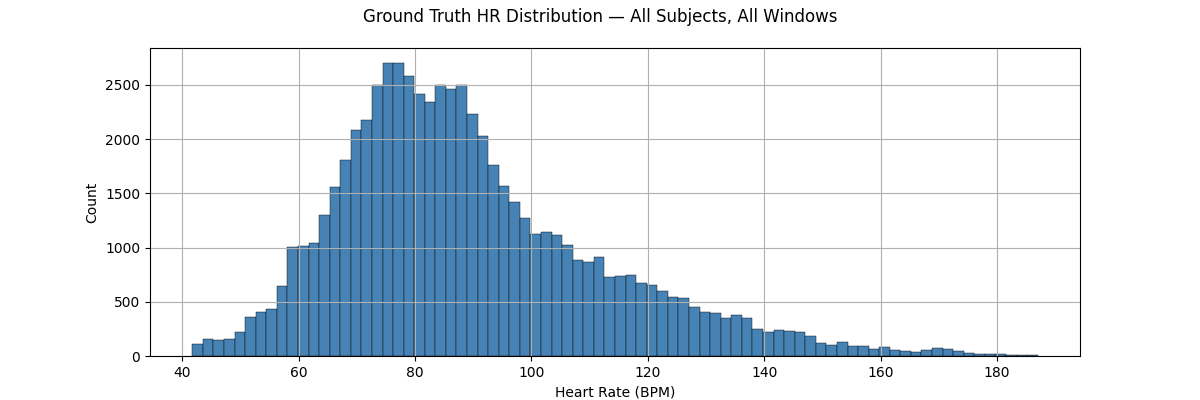

In [3]:
# Ground truth HR distribution across all subjects

all_labels = np.concatenate([data_preproc[s]['label'] for s in data_preproc])

print(f"Min HR:  {all_labels.min():.1f} BPM")
print(f"Max HR:  {all_labels.max():.1f} BPM")
print(f"Mean HR: {all_labels.mean():.1f} BPM")
print(f"Std HR:  {all_labels.std():.1f} BPM")
print(f"Total windows: {len(all_labels)}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(all_labels, bins=80, color='steelblue', edgecolor='k', linewidth=0.3)
ax.set_xlabel('Heart Rate (BPM)')
ax.set_ylabel('Count')
ax.grid(True)
plt.suptitle('Ground Truth HR Distribution — All Subjects, All Windows')
plt.show()

## Ground truth HR stats

- HRs range [~40, ~190] for this dataset
- BPF already applied 24 - 240 BPM, but prediction alg can be more aggressive in filtering while still covering normal human range

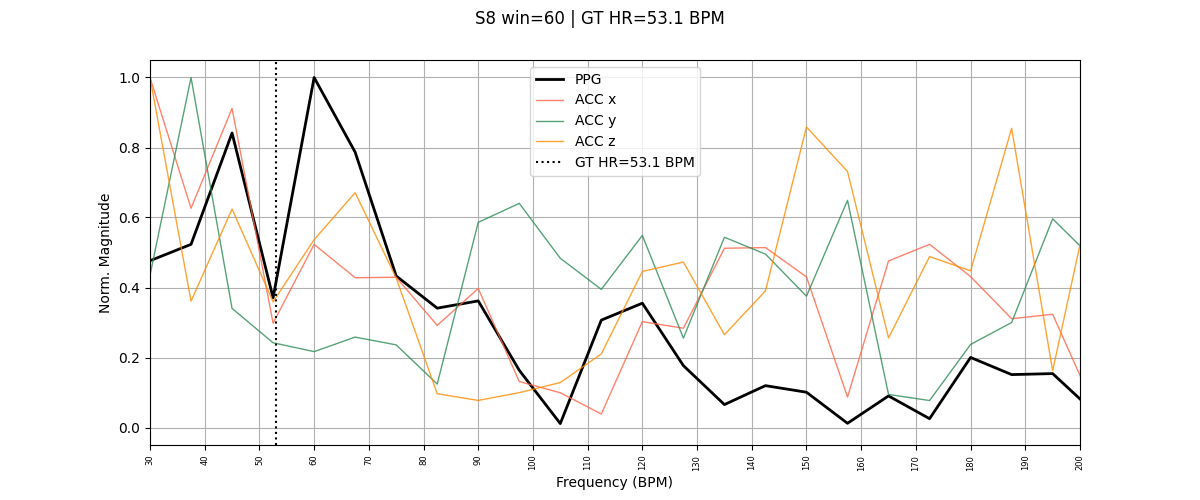

In [4]:
# Single window inspection

SUBJ_TEST = 'S8'
WIN_TEST  = 60

ppg_win = data_preproc[SUBJ_TEST]['ppg'][WIN_TEST, :, 0]  # (N_WIN,)
acc_win = data_preproc[SUBJ_TEST]['acc'][WIN_TEST]         # (N_WIN, 3)
hr_gt   = data_preproc[SUBJ_TEST]['label'][WIN_TEST]

f_hz  = rfftfreq(N_WIN, d=1/FS)
f_bpm = f_hz * 60

X_ppg  = np.abs(rfft(ppg_win))
X_ppg /= np.max(X_ppg)

X_acc = np.abs(rfft(acc_win, axis=0))
X_acc /= np.max(X_acc, axis=0)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(f_bpm, X_ppg,       lw=2.0, color='k',          label='PPG')
ax.plot(f_bpm, X_acc[:, 0], lw=1.0, color='tomato',     label='ACC x', alpha=0.8)
ax.plot(f_bpm, X_acc[:, 1], lw=1.0, color='seagreen',   label='ACC y', alpha=0.8)
ax.plot(f_bpm, X_acc[:, 2], lw=1.0, color='darkorange',  label='ACC z', alpha=0.8)
ax.axvline(hr_gt, color='k', linestyle=':', lw=1.5, label=f'GT HR={hr_gt:.1f} BPM')
ax.set_xlabel('Frequency (BPM)')
ax.set_ylabel('Norm. Magnitude')
ax.set_xlim(30, 200)
bpm_ticks = np.arange(30, 200 + 1, 10)
ax.set_xticks(bpm_ticks)
ax.set_xticklabels([f'{int(b)}' for b in bpm_ticks], fontsize=6, rotation=90)
ax.legend()
ax.grid(True)
plt.suptitle(f'{SUBJ_TEST} win={WIN_TEST} | GT HR={hr_gt:.1f} BPM')
plt.show()

SNR min:    26.38 dB
SNR max:    136.06 dB
SNR mean:   59.36 dB
SNR median: 57.07 dB
SNR std:    11.82 dB


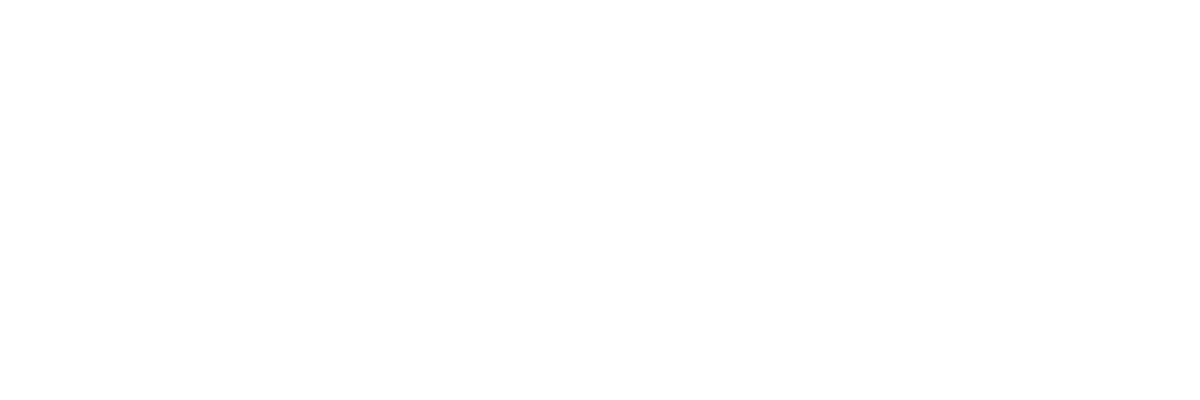

In [5]:
# SNR distribution over entire dataset — using BPF (unnormalized) windows

snr_values = []

for subj_id, d in data_preproc.items():
    n_windows = d['ppg_bpf'].shape[0]
    for i in range(n_windows):
        ppg_win = d['ppg_bpf'][i]      # (N_WIN, 1)
        acc_win = d['acc_bpf'][i]      # (N_WIN, 3)

        X_ppg = np.abs(rfft(ppg_win[:, 0]))
        X_acc = np.abs(rfft(acc_win, axis=0))

        ppg_pwr     = np.mean(X_ppg ** 2)
        acc_pwr_avg = np.mean(X_acc ** 2)
        snr_db      = 10 * np.log10(ppg_pwr / (acc_pwr_avg + 1e-12))

        snr_values.append(snr_db)

snr_values = np.array(snr_values)

print(f"SNR min:    {snr_values.min():.2f} dB")
print(f"SNR max:    {snr_values.max():.2f} dB")
print(f"SNR mean:   {snr_values.mean():.2f} dB")
print(f"SNR median: {np.median(snr_values):.2f} dB")
print(f"SNR std:    {snr_values.std():.2f} dB")

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(snr_values, bins=100, color='steelblue', edgecolor='k', linewidth=0.3)
ax.set_xlabel('SNR (dB)')
ax.set_ylabel('Count')
ax.grid(True)
plt.suptitle('PPG/ACC SNR Distribution — All Subjects, All Windows (BPF unnormalized)')
plt.tight_layout()
plt.show()

In [6]:
def hr_est_spectral(ppg_win, acc_win, hr_prev, hr_delta,
                    snr_threshold, npeaks_keep, penalty_factor, hr_min = 30, hr_max = 200, fs=FS):
    """
    Frequency-domain HR estimation with ACC-based spectral subtraction.

    Pipeline:
        1. Compute PPG and ACC magnitude spectra via rFFT
        2. Compute SNR proxy: 10*log10(ppg_pwr / mean(acc_pwr per channel))
           If snr < snr_threshold and hr_prev is not None: return hr_prev
        3. Mask spectrum to physiological HR range [hr_min, hr_max]
        4. If hr_prev is not None: further mask to [hr_prev-hr_delta, hr_prev+hr_delta]
        5. Select top npeaks_keep PPG spectral peaks by magnitude
        6. For each candidate peak, apply penalty_factor for each ACC channel
           whose peak BPM falls within +-1 FFT bin of the candidate
        7. Return BPM of highest remaining (possibly penalized) peak

    Args:
        ppg_win:        (N, 1)   normalized PPG window
        acc_win:        (N, 3)   normalized ACC window
        hr_prev:        float or None  previous HR estimate in BPM
        hr_min:         float    minimum physiological HR in BPM
        hr_max:         float    maximum physiological HR in BPM
        hr_delta:       float    max allowable HR change per window in BPM
        snr_threshold:  float    minimum SNR (dB) to attempt estimation
        npeaks_keep:    int      number of top PPG peaks to evaluate
        penalty_factor: float    multiplicative penalty [0, 1] applied to PPG
                                 peaks that match ACC spectral content
        fs:             int      sample rate in Hz

    Returns:
        hr_est:         float    estimated HR in BPM
    """

    assert ppg_win.ndim == 2 and ppg_win.shape[1] == 1, "ppg_win must be (N, 1)"
    assert acc_win.ndim == 2,                            "acc_win must be (N, channels)"
    assert ppg_win.shape[0] == acc_win.shape[0],         "ppg and acc must have equal length"
    assert 0 <= penalty_factor <= 1,                     "penalty_factor must be in [0, 1]"
    assert npeaks_keep >= 1,                             "npeaks_keep must be >= 1"

    N         = ppg_win.shape[0]
    n_acc_ch  = acc_win.shape[1]
    f_hz      = rfftfreq(N, d=1/fs)
    f_bpm     = f_hz * 60
    bin_width = f_bpm[1] - f_bpm[0]  # BPM per FFT bin

    # --- Step 1: Magnitude spectra ---
    X_ppg = np.abs(rfft(ppg_win[:, 0]))          # (N//2+1,)
    X_acc = np.abs(rfft(acc_win, axis=0))         # (N//2+1, channels)

    # --- Step 2: SNR gate ---
    ppg_pwr     = np.mean(X_ppg ** 2)
    acc_pwr_avg = np.mean(X_acc ** 2)
    snr_db      = 10 * np.log10(ppg_pwr / (acc_pwr_avg + 1e-12))

    if snr_db < snr_threshold and hr_prev is not None:
        return hr_prev

    # --- Step 3: Physiological range mask ---
    phys_mask       = (f_bpm >= hr_min) & (f_bpm <= hr_max)
    X_ppg_masked    = X_ppg * phys_mask

    # --- Step 4: hr_prev delta mask ---
    delta_mask = np.ones_like(f_bpm)
    if hr_prev is not None:
        delta_mask   = (f_bpm >= hr_prev - hr_delta) & (f_bpm <= hr_prev + hr_delta)
        X_ppg_masked = X_ppg_masked * delta_mask

    # --- Step 5: Select top npeaks_keep candidate peaks ---
    # Argsort descending, keep top npeaks_keep nonzero indices
    sorted_idx  = np.argsort(X_ppg_masked)[::-1]
    nonzero_idx = [i for i in sorted_idx if X_ppg_masked[i] > 0]
    candidates  = nonzero_idx[:npeaks_keep]

    if len(candidates) == 0:
        return hr_prev if hr_prev is not None else f_bpm[np.argmax(X_ppg * phys_mask)]

    # --- Step 6: ACC penalty ---
    peak_scores = {}
    for idx in candidates:
        score = X_ppg_masked[idx]

        for c in range(n_acc_ch):
            # Get top npeaks_keep ACC peaks in same masked range
            X_acc_ch     = X_acc[:, c] * phys_mask * delta_mask
            sorted_acc   = np.argsort(X_acc_ch)[::-1]
            nonzero_acc  = [i for i in sorted_acc if X_acc_ch[i] > 0]
            acc_peaks    = nonzero_acc[:npeaks_keep]

            # Expand each acc peak index by +-1 bin and take unique
            if len(acc_peaks) == 0:
                continue
            acc_idx_expanded = np.unique(
                np.concatenate([[i-1, i, i+1] for i in acc_peaks])
            )

            # Penalize if candidate index falls in expanded acc peak set
            if idx in acc_idx_expanded:
                score *= penalty_factor

        peak_scores[idx] = score

    # --- Step 7: Return highest remaining peak ---
    best_idx = max(peak_scores, key=peak_scores.get)
    return f_bpm[best_idx]

In [14]:
# Parameter sweep — classical HR estimation
# Random (subject, chunk) trials — chronological within each chunk

from itertools import product

N_TRIALS   = 250
CHUNK_SIZE = 25

HR_DELTA_VALUES      = [45., 50., 55., 60., 65.]
SNR_THRESHOLD_VALUES = [63., 63.5, 64.]
NPEAKS_KEEP_VALUES   = [3]
PENALTY_VALUES       = [0.655, 0.66, 0.665]

rng      = np.random.default_rng(42)
subjects = list(data_preproc.keys())

# Pre-sample trials — (subject, chunk_start) pairs
trials = []
for _ in range(N_TRIALS):
    subj_id     = rng.choice(subjects)
    n_windows   = data_preproc[subj_id]['ppg_bpf'].shape[0]
    chunk_start = int(rng.integers(0, max(1, n_windows - CHUNK_SIZE)))
    trials.append((subj_id, chunk_start))

param_grid = list(product(
    HR_DELTA_VALUES,
    SNR_THRESHOLD_VALUES,
    NPEAKS_KEEP_VALUES,
    PENALTY_VALUES,
))

print(f"Total parameter combinations : {len(param_grid)}")
print(f"Total trials per combination : {N_TRIALS}")
print(f"Total windows per combination: {N_TRIALS * CHUNK_SIZE}\n")

sweep_results = []

for idx, (hr_delta, snr_thresh, npeaks, penalty) in enumerate(param_grid):
    all_est   = []
    all_label = []

    for subj_id, chunk_start in trials:
        d       = data_preproc[subj_id]
        hr_prev = None

        end = min(chunk_start + CHUNK_SIZE, d['ppg_bpf'].shape[0])
        for i in range(chunk_start, end):
            ppg_win = d['ppg_bpf'][i]
            acc_win = d['acc_bpf'][i]
            label   = d['label'][i]

            hr_est = hr_est_spectral(
                ppg_win        = ppg_win,
                acc_win        = acc_win,
                hr_prev        = hr_prev,
                hr_delta       = hr_delta,
                snr_threshold  = snr_thresh,
                npeaks_keep    = npeaks,
                penalty_factor = penalty,
            )

            all_est.append(hr_est)
            all_label.append(label)
            hr_prev = hr_est

    mae = np.mean(np.abs(np.array(all_est) - np.array(all_label)))
    sweep_results.append({
        'hr_delta':      hr_delta,
        'snr_threshold': snr_thresh,
        'npeaks_keep':   npeaks,
        'penalty':       penalty,
        'mae':           mae,
    })

    if (idx + 1) % 10 == 0 or (idx + 1) == len(param_grid):
        print(f"[{idx+1:>4}/{len(param_grid)}] "
              f"hr_delta={hr_delta:>5.3f}  snr={snr_thresh:>5.3f}  "
              f"npeaks={npeaks:>2d}  penalty={penalty:.3f}  "
              f"MAE={mae:.3f} BPM")

sweep_results.sort(key=lambda x: x['mae'])

print(f"\nTop 10 parameter combinations:")
print(f"{'hr_delta':>10} {'snr_thresh':>12} {'npeaks':>8} {'penalty':>9} {'MAE':>8}")
print("-" * 55)
for r in sweep_results[:10]:
    print(f"{r['hr_delta']:>10.3f} {r['snr_threshold']:>12.3f} "
          f"{r['npeaks_keep']:>8d} {r['penalty']:>9.3f} {r['mae']:>8.3f}")

Total parameter combinations : 45
Total trials per combination : 250
Total windows per combination: 6250

[  10/45] hr_delta=50.000  snr=63.000  npeaks= 3  penalty=0.655  MAE=16.877 BPM
[  20/45] hr_delta=55.000  snr=63.000  npeaks= 3  penalty=0.660  MAE=16.912 BPM
[  30/45] hr_delta=60.000  snr=63.000  npeaks= 3  penalty=0.665  MAE=17.079 BPM
[  40/45] hr_delta=65.000  snr=63.500  npeaks= 3  penalty=0.655  MAE=16.516 BPM
[  45/45] hr_delta=65.000  snr=64.000  npeaks= 3  penalty=0.665  MAE=16.993 BPM

Top 10 parameter combinations:
  hr_delta   snr_thresh   npeaks   penalty      MAE
-------------------------------------------------------
    60.000       63.500        3     0.660   16.494
    65.000       63.500        3     0.660   16.494
    60.000       63.500        3     0.655   16.516
    65.000       63.500        3     0.655   16.516
    60.000       63.500        3     0.665   16.649
    65.000       63.500        3     0.665   16.649
    55.000       63.500        3     0.655

In [15]:
# Full dataset run with optimal values from above cell
#
# Achieved sparse test MAE ~16.5 BPM

HR_DELTA_TEST   = 65.0
SNR_THRESH_TEST = 63.5
NPEAK_TEST      = 3
PENALTY_TEST    = 0.66

data_est = {}

for subj_id, d in data_preproc.items():
    n_windows  = d['ppg_bpf'].shape[0]
    hr_est_arr = np.zeros(n_windows)
    hr_prev    = None

    for i in range(n_windows):
        ppg_win = d['ppg_bpf'][i]
        acc_win = d['acc_bpf'][i]

        hr_est = hr_est_spectral(
            ppg_win        = ppg_win,
            acc_win        = acc_win,
            hr_prev        = hr_prev,
            hr_delta       = HR_DELTA_TEST,
            snr_threshold  = SNR_THRESH_TEST,
            npeaks_keep    = NPEAK_TEST,
            penalty_factor = PENALTY_TEST,
        )

        hr_est_arr[i] = hr_est
        hr_prev       = hr_est

    data_est[subj_id] = {
        'hr_est':  hr_est_arr,
        'hr_label': d['label'],
    }

    mae = np.mean(np.abs(hr_est_arr - d['label']))
    print(f"{subj_id} — MAE: {mae:.2f} BPM")

all_est   = np.concatenate([data_est[s]['hr_est']   for s in data_est])
all_label = np.concatenate([data_est[s]['hr_label'] for s in data_est])
mae_total = np.mean(np.abs(all_est - all_label))
print(f"\nOverall MAE: {mae_total:.2f} BPM")

S1 — MAE: 13.88 BPM
S2 — MAE: 15.03 BPM
S3 — MAE: 18.94 BPM
S4 — MAE: 12.56 BPM
S5 — MAE: 46.46 BPM
S6 — MAE: 17.56 BPM
S7 — MAE: 17.18 BPM
S8 — MAE: 18.75 BPM
S9 — MAE: 23.45 BPM
S10 — MAE: 16.24 BPM
S11 — MAE: 19.80 BPM
S12 — MAE: 15.27 BPM
S13 — MAE: 15.30 BPM
S14 — MAE: 21.28 BPM
S15 — MAE: 14.94 BPM

Overall MAE: 19.24 BPM


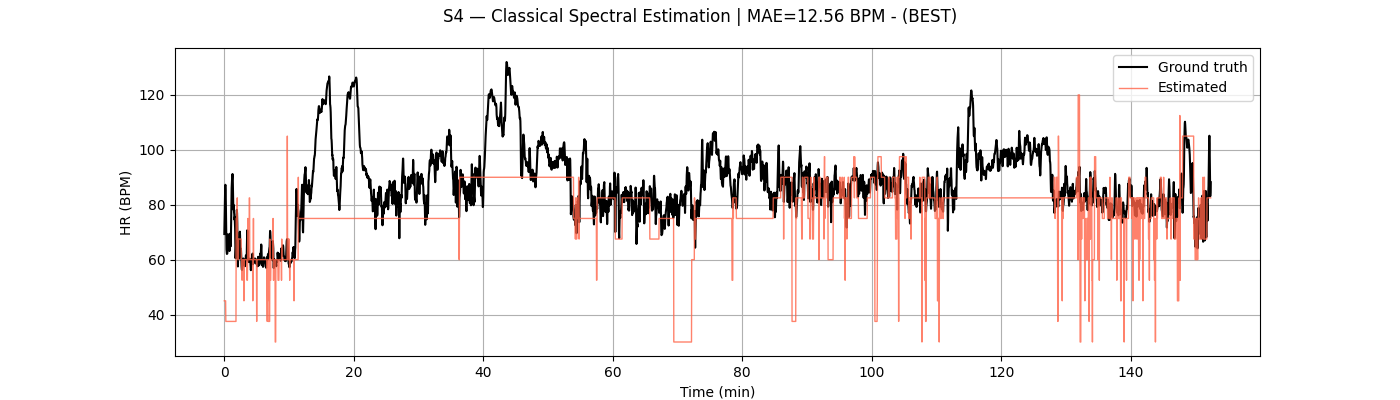

In [16]:
# Plot estimated vs ground truth HR for a single subject

SUBJ_PLOT = 'S4'

hr_est   = data_est[SUBJ_PLOT]['hr_est']
hr_label = data_est[SUBJ_PLOT]['hr_label']
t        = np.arange(len(hr_label)) * T_STRIDE / 60  # time in minutes

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(t, hr_label, lw=1.5, color='k',        label='Ground truth')
ax.plot(t, hr_est,   lw=1.0, color='tomato',   label='Estimated', alpha=0.8)
ax.set_xlabel('Time (min)')
ax.set_ylabel('HR (BPM)')
ax.legend()
ax.grid(True)
mae_subj = np.mean(np.abs(hr_est - hr_label))
plt.suptitle(f'{SUBJ_PLOT} — Classical Spectral Estimation | MAE={mae_subj:.2f} BPM - (BEST)')
plt.show()

## Classical Method Notes
- Manual param sweep suggested best algo performance with:
  - HR_DELTA_TEST   = 65.0
  - SNR_THRESH_TEST = 63.5
  - NPEAK_TEST      = 3
  - PENALTY_TEST    = 0.66
- These parameters were then run on full dataset, yielding overall MAE of 19.24 BPM
- Even in the best case (MAE ~12 BPM on S4), performance is poor
- As ground truth / estimate plot shows, algorithm often underestimates or latches onto
  previous estimate value — a consequence of the hr_prev fallback mechanism and the
  hr_delta tracking constraint
- FFT bin resolution at 8s windows / 32 Hz imposes hard frequency quantization floor
  of 7.5 BPM, contributing irreducible error independent of the algorithm
- Method is similar to SpaMa from the DeepPPG paper but underperforms that benchmark — SpaMa uses a more complex spectral subtraction with additional post-processing
- Results confirm PPG-DaLiA is difficult dataset: motion artifact
  from varied activities (cycling, table soccer, stairs) overlaps spectrally
  with the cardiac band, which linear/classical methods cannot resolve
- Classical method could be improved with:
  - Exponential averaging across more than one previous window
  - More sophisticated spectral subtraction (e.g. TROIKA-style sparse reconstruction)
  - A latching detector to break out of prolonged hr_prev fallback chains
  - Signal quality gating based on ACC magnitude rather than PPG/ACC SNR ratio